# Reading profiles

Image-based profiling pipelines hand you a table: one row per well or per cell, a few hundred columns of CellProfiler measurements, and a handful of metadata columns mixed in among them.
{func}`~mantispy.io.read_profiles` turns one or many of those tables into an {class}`~anndata.AnnData`, splitting the measurements from the metadata and annotating what each feature name encodes.

In [1]:
import mantispy as mt

## One plate

{mod}`mantispy.ds` downloads a few plates from the [Cell Painting Gallery](https://github.com/broadinstitute/cellpainting-gallery) so that there is something real to read.
This is one plate of the JUMP pilot, already normalized against the negative controls of its batch and feature-selected.

In [2]:
adata = mt.ds.cpjump1()
adata

  0%|                                              | 0.00/1.16M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 384 × 904
    obs: 'broad_sample', 'solvent', 'Plate', 'Well', 'InChIKey', 'pert_iname', 'pubchem_cid', 'gene', 'pert_type', 'control_type', 'smiles', 'target_sequence', 'negcon_control_type'
    var: 'compartment', 'family', 'channel', 'channel_2', 'n_channels'
    layers: None (.X)

Numeric columns became the feature matrix and everything else became `obs`.
The `Metadata_` prefix the pipeline wrote is stripped, so the perturbation of each well reads as `pert_iname` rather than `Metadata_pert_iname`.

In [3]:
adata.obs.head()

,broad_sample,solvent,Plate,Well,InChIKey,pert_iname,pubchem_cid,gene,pert_type,control_type,smiles,target_sequence,negcon_control_type
observation,,,,,,,,,,,,,
BR00116991:A01,BRD-A86665761-001-01-1,DMSO,BR00116991,A01,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883900.0,CACNB4,trt,<NA>,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,NaN,NaN
BR00116991:A02,<NA>,DMSO,BR00116991,A02,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,DMSO,679.0,<NA>,control,negcon,CS(=O)C,NaN,NaN
BR00116991:A03,BRD-A22032524-074-09-9,DMSO,BR00116991,A03,HTIQEAQVCYTUBX-UHFFFAOYSA-N,amlodipine,2162.0,CACNA2D3,trt,<NA>,CCOC(=O)C1=C(COCCN)NC(C)=C(C1c1ccccc1Cl)C(=O)OC,NaN,NaN
BR00116991:A04,BRD-A01078468-001-14-8,DMSO,BR00116991,A04,PBBGSZCBWVPOOL-UHFFFAOYSA-N,hexestrol,3606.0,AKR1C1,trt,<NA>,CCC(C(CC)c1ccc(O)cc1)c1ccc(O)cc1,NaN,NaN
BR00116991:A05,BRD-K48278478-001-01-2,DMSO,BR00116991,A05,LOUPRKONTZGTKE-AFHBHXEDSA-N,quinine,94175.0,KCNN4,trt,<NA>,COc1ccc2nccc([C@@H](O)[C@H]3C[C@@H]4CC[N@]3C[C...,NaN,NaN


## What a feature name says

CellProfiler names a feature `<compartment>_<family>_<measurement>[_<channel>]`, and {func}`~mantispy.io.read_profiles` pulls that apart into `var`.
`Correlation` features measure colocalization between a pair of channels, so they carry two; `AreaShape` is geometry and carries none.

In [4]:
adata.var.head()

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_BoundingBoxMaximum_Y,cells,areashape,NaN,NaN,0
Cells_AreaShape_Compactness,cells,areashape,NaN,NaN,0
Cells_AreaShape_Eccentricity,cells,areashape,NaN,NaN,0
Cells_AreaShape_Extent,cells,areashape,NaN,NaN,0
Cells_AreaShape_Solidity,cells,areashape,NaN,NaN,0


In [5]:
adata.var.groupby(["compartment", "family"], observed=True).size().sort_values(ascending=False).head(10)

compartment  family            
nuclei       texture               143
             correlation            76
cells        correlation            76
cytoplasm    correlation            75
             texture                72
nuclei       granularity            55
cytoplasm    granularity            47
cells        radialdistribution     45
nuclei       radialdistribution     44
cells        texture                38
dtype: int64

That makes it easy to ask for a slice of the measurements by what they mean rather than by string matching:

In [6]:
dna_intensity = adata[:, (adata.var["channel"] == "dna") & (adata.var["family"] == "intensity")]
dna_intensity.shape

(384, 14)

## Several plates at once

Pass a list of files to stack them row-wise.
Real screens rarely agree with themselves: feature selection runs per plate, so two plates of the same batch can end up with different columns.
`on_column_mismatch` decides what happens then — `"raise"`, the default, or `"intersect"` to keep what the plates share.

The LINCS dataset here is two such plates.

In [7]:
lincs = mt.ds.lincs()
lincs

  0%|                                               | 0.00/495k [00:00<?, ?B/s]

  0%|                                               | 0.00/563k [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 768 × 291
    obs: 'plate_map_name', 'broad_sample', 'mg_per_ml', 'mmoles_per_liter', 'solvent', 'Plate', 'Well', 'pert_id', 'pert_mfc_id', 'pert_well', 'pert_id_vendor', 'cell_id', 'broad_sample_type', 'pert_vehicle', 'pert_type', 'broad_id', 'pert_iname', 'InChIKey14', 'moa', 'target', 'broad_date', 'clinical_phase', 'alternative_moa', 'alternative_target', 'Assay_Plate_Barcode', 'Plate_Map_Name', 'Batch_Number', 'Batch_Date', 'dose_recode'
    var: 'compartment', 'family', 'channel', 'channel_2', 'n_channels'
    layers: None (.X)

In [8]:
lincs.obs.groupby("Plate", observed=True).size()

Plate
SQ00015116    384
SQ00015117    384
dtype: int64

## Sentinels, indices and path metadata

The remaining arguments cover what has actually differed between datasets:

```python
adata = mt.io.read_profiles(
    sorted(Path("profiles").glob("*/*.parquet")),
    sentinels=-999,                          # values standing for missing, replaced with NaN
    index_columns=("Plate", "Well"),         # joined with ":" into the observation index
    metadata_columns=("ImageNumber",),       # numeric columns that are not features
    path_columns={"Metadata_Batch": 2},      # metadata read off the file path
    on_column_mismatch="intersect",
)
```

`path_columns` maps a column name to how many directories up from the file to read the name of, which is how a batch or a plate that only exists in the directory layout gets into `obs`.

## A first look at the structure

The profiles are ready for the rest of the scverse ecosystem at this point.

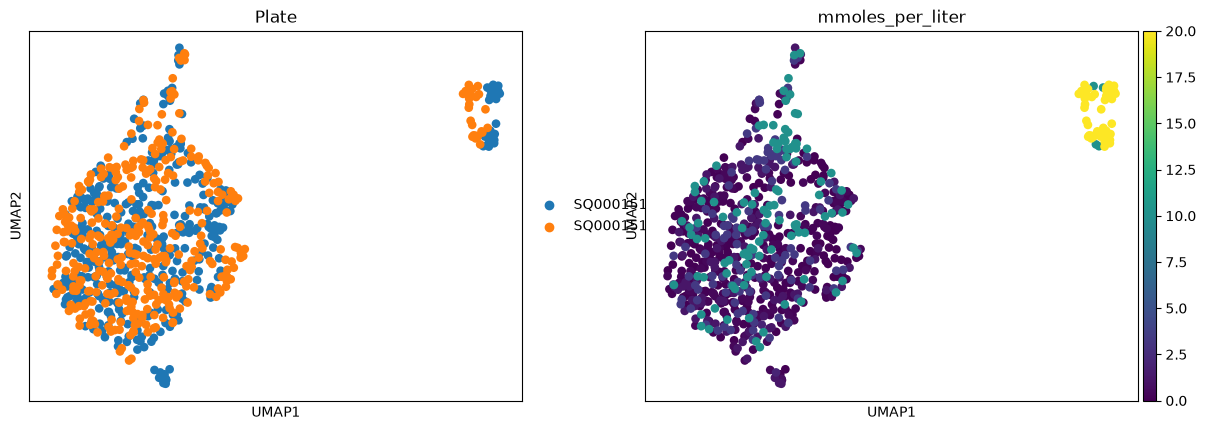

In [9]:
import scanpy as sc

sc.pp.pca(lincs)
sc.pp.neighbors(lincs)
sc.tl.umap(lincs)
sc.pl.umap(lincs, color=["Plate", "mmoles_per_liter"], ncols=2)

The two plates separate, which is the batch effect a real analysis would have to correct before reading anything into the rest of the picture.